In [34]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import pearsonr

# plot setting
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6.5

plt.rcParams['axes.titlesize'] = 6.5
plt.rcParams['axes.labelsize'] = 6.5
plt.rcParams['axes.labelpad'] = 3
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.75

plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['xtick.labelsize'] = 6.5
plt.rcParams['ytick.labelsize'] = 6.5
plt.rcParams['xtick.major.width'] = 0.75
plt.rcParams['ytick.major.width'] = 0.75
plt.rcParams['xtick.major.pad'] = 2
plt.rcParams['ytick.major.pad'] = 2

### iRT peptides

In [2]:
iRT_list = pd.read_csv('C:/Users/chenxin/Desktop/BrIS_latest/iRT_peptides_library.csv', index_col = 0)
iRT_list

,sequence,iRT
name,,
pep a,LGGNEQVTR,-24.92
pep b,GAGSSEPVTGLDAK,0.00
pep c,VEATFGVDESNAK,12.39
pep d,YILAGVENSK,19.79
pep e,TPVISGGPYEYR,28.71
pep f,TPVITGAPYEYR,33.38
pep g,DGLDAASYYAPVR,42.26
pep h,ADVTPADFSEWSK,54.62
pep i,GTFIIDPGGVIR,70.52


### process background peptides identified from tims1, tims2 and exploris480

In [3]:
def process_bpep_results(bpep_file, NA_rates = 0.5):
    df = pd.read_table(bpep_file)
    df = df.drop_duplicates(subset = ['PEP.StrippedSequence'], keep = 'first').copy()
    df = df.set_index('PEP.StrippedSequence')
    bpep_RT = df[[col for col in df.columns if 'RT' in col]]
    bpep_RT.columns = [f'S{i:02d}' for i in range(1, bpep_RT.shape[1]+1)]
    bpep_RT = bpep_RT.apply(pd.to_numeric, errors = 'coerce')
    # delete peptides with >50% NA and impute NA with median  
    bpep_NA_rates = bpep_RT.isna().mean(axis = 1)
    bpep_RT = bpep_RT[bpep_NA_rates <= NA_rates].copy()
    bpep_RT_filled = bpep_RT.copy()
    for peptide in bpep_RT_filled.index:
        RT_across_samples = bpep_RT_filled.loc[peptide]
        if RT_across_samples.isna().any():
            median_value = RT_across_samples.median()
            bpep_RT_filled.loc[peptide] = RT_across_samples.fillna(median_value)
    return bpep_RT_filled
tims1_bpep_RT_filled = process_bpep_results('D:/project/04BrIS/across_platform/20251112_tim1_results.tsv')
tims2_bpep_RT_filled = process_bpep_results('D:/project/04BrIS/across_platform/20251112_tim2_results.tsv')
exploris480_bpep_RT_filled = process_bpep_results('D:/project/04BrIS/across_platform/20251124_480_results.tsv')

### overlap of background peptides: tims1 and tims2, tims1 and exploris480

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2(set1, set2, label1, label2, color1, color2, filename):
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    overlap = len(set1 & set2)
    plt.figure(figsize = (2.0, 1.7))
    v = venn2(subsets = (1, 1, 1), set_labels = (label1, label2))
    v.get_label_by_id('10').set_text(f'{only1}') 
    v.get_label_by_id('01').set_text(f'{only2}') 
    v.get_label_by_id('11').set_text(f'{overlap}')
    for p_id in ['10', '01', '11']:
        patch = v.get_patch_by_id(p_id)
        if patch:
            patch.set_color('none')
            patch.set_alpha(1.0)
    c = venn2_circles(subsets = (1, 1, 1), linewidth = 0.5, alpha = 1.0)
    c[0].set_edgecolor(color1) 
    c[1].set_edgecolor(color2) 
    for text in v.set_labels:
        if text: 
            text.set_fontsize(6.5)
            text.set_y(-0.5)
    for text in v.subset_labels:
        if text: 
            text.set_fontsize(6.5)
    plt.savefig(filename, format = 'pdf', bbox_inches = 'tight', pad_inches=0)    
    plt.show()

In [5]:
tims1_peptides = set(tims1_bpep_RT_filled.index)
tims2_peptides = set(tims2_bpep_RT_filled.index)
exploris480_peptides = set(exploris480_bpep_RT_filled.index)

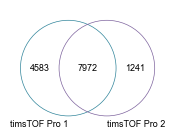

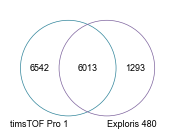

In [5]:
plot_venn2(tims1_peptides, tims2_peptides, 'timsTOF Pro 1', 'timsTOF Pro 2', '#31859B', '#7E649E',
          'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/cross_platforms/tims1_tims2_background_peptides_overlap.pdf')
plot_venn2(tims1_peptides, exploris480_peptides, 'timsTOF Pro 1', 'Exploris 480', '#31859B', '#7E649E',
          'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/cross_platforms/tims1_480_background_peptides_overlap.pdf')

## Polynomial Regression Fitting

In [6]:
PR = {'LR':1}

### Fit iRT-peptide iRT vs RT (tims1, Spectronaut)

In [7]:
def read_iRT_file(iRT_file, iRT_list):
    iRT_df = pd.read_csv(iRT_file, index_col = 1)
    
    RT_cols = [col for col in iRT_df.columns if 'RT' in col]
    iRT_df = iRT_df[RT_cols]
    new_cols = [f'S{i:02d}' for i in range(1, iRT_df.shape[1]+1)]
    iRT_df.columns = new_cols
    
    sequence_to_pep = dict(zip(iRT_list['sequence'], iRT_list.index))
    iRT_df_reordered = iRT_df.reindex(index = iRT_list['sequence'])
    iRT_df_reordered.index = iRT_df_reordered.index.map(sequence_to_pep)
    return iRT_df_reordered

In [8]:
tims1_iRT = read_iRT_file('C:/Users/chenxin/Desktop/tmp_results/20251112_tim1_iRT.csv', iRT_list)
tims1_iRT

,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,S13,S14,S15,S16,S17
sequence,,,,,,,,,,,,,,,,,
pep a,9.903195,10.919953,10.216776,10.021474,10.072130,9.837916,9.882512,9.867001,9.823930,9.688078,9.935026,9.815907,9.863908,9.928548,10.118888,10.254502,10.320427
pep b,15.816897,17.496433,16.829002,16.365969,16.368608,15.995203,15.804358,15.995200,15.843785,15.645585,15.944809,15.785513,15.894919,15.767106,15.939479,16.115917,16.860588
pep c,18.403229,20.221968,19.829975,19.366917,19.123308,18.697039,18.450150,18.678562,18.633595,18.507793,18.828270,18.695564,18.725594,18.580624,18.712822,19.031298,19.751944
pep d,21.077734,22.964264,22.841576,22.127180,21.974438,21.533272,21.226479,21.500454,21.549072,21.546553,21.765049,21.637562,21.624704,21.621269,21.760082,22.037655,22.752941
pep e,22.996647,24.863056,24.329559,23.724899,23.585522,23.189121,22.958088,23.161900,23.217247,23.227268,23.400238,23.237892,23.233414,23.307297,23.387617,23.639343,24.420250
pep f,25.249218,27.139400,26.710491,26.006840,25.904886,25.523222,25.285780,25.454683,25.515547,25.482800,25.580578,25.490307,25.410938,25.615936,25.715006,25.984253,26.563242
pep g,28.868969,30.821892,30.288605,29.617001,29.531487,29.120754,28.963074,29.169636,29.209372,29.240492,29.198727,29.084356,29.111616,29.357368,29.378635,29.604942,30.342253
pep h,31.617002,33.871769,33.119335,32.352345,32.359325,32.012733,31.808958,31.969950,32.053818,32.129131,32.028954,31.988874,31.910414,32.141483,32.243244,32.588772,33.214874
pep i,42.181656,44.823711,44.258141,43.393768,43.250160,42.943520,42.735462,42.994186,42.923168,42.783081,42.826916,42.703964,42.842319,43.038803,42.987778,43.323776,43.852184


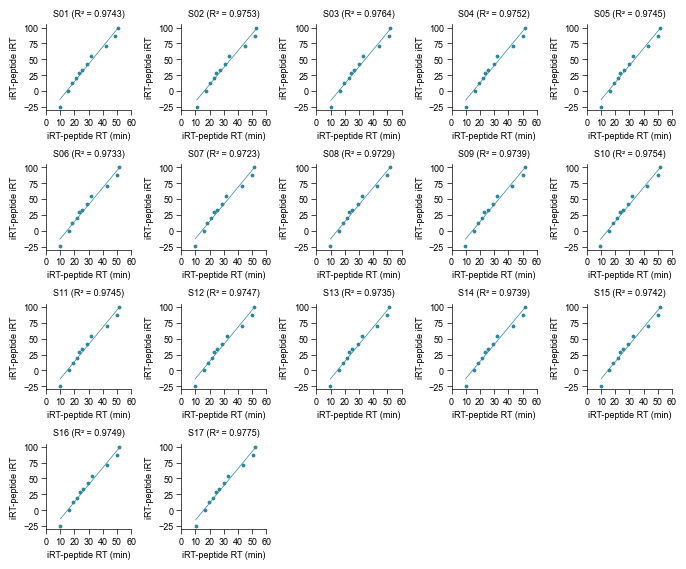

In [9]:
tims1_fit_results = {}
for sample in tims1_iRT.columns:
    iRT_RT_array = tims1_iRT[sample].values
    iRT_iRT_array = iRT_list['iRT'].values
    x = iRT_RT_array.reshape(-1, 1)
    y = iRT_iRT_array
    # Generate smooth x values for plotting fit curve
    x_fit = np.linspace(min(iRT_RT_array), max(iRT_RT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': iRT_RT_array,
            'iRT': iRT_iRT_array
        }
    tims1_fit_results[sample] = sample_results

# Plot fit results
fig, axes = plt.subplots(4, 5, figsize=(6.85, 5.68))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(tims1_fit_results):
    ax = axes[i]
    iRT_RT_array = tims1_fit_results[sample][model_name]['RT']
    iRT_iRT_array = tims1_fit_results[sample][model_name]['iRT']
    ax.scatter(iRT_RT_array, iRT_iRT_array, color = color, alpha = 1.0, s = 3)
    x_fit = tims1_fit_results[sample][model_name]['x_fit']
    y_fit = tims1_fit_results[sample][model_name]['y_fit']
    r2 = tims1_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(0, 60)
    ax.set_ylim(-30, 105)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_yticks([-25, 0, 25, 50, 75, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('iRT-peptide RT (min)')
    ax.set_ylabel('iRT-peptide iRT')
    ax.set_title(f'{sample} (R² = {tims1_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(tims1_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure5/Supplementary_Figure5_{model_name}_fit_iRT_peptide_iRT_vs_RT_TIMS1.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### Fit iRT-peptide RT (tims2, Spectronaut) vs iRT

In [10]:
tims2_iRT = read_iRT_file('C:/Users/chenxin/Desktop/tmp_results/20251112_tim2_iRT_10_samples.csv', iRT_list)
tims2_iRT

,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10
sequence,,,,,,,,,,
pep a,10.872024,10.868153,10.708324,10.872444,10.777200,10.872408,10.765393,10.929294,11.001060,10.986081
pep b,20.475916,20.478155,20.543842,20.408539,20.482967,20.448299,20.471140,20.516233,20.576761,20.516878
pep c,24.158375,24.160769,24.311089,24.249140,24.391518,24.238060,24.289124,24.260868,24.253557,24.193569
pep d,27.621599,27.521980,27.791218,27.689472,27.758663,27.655914,27.689836,27.639244,27.614883,27.690422
pep e,29.614498,29.616608,29.806751,29.750080,29.757317,29.682562,29.756069,29.682905,29.658691,29.671953
pep f,31.989349,31.991425,32.057156,32.023022,32.036083,32.085487,32.130749,32.091522,32.022308,32.057961
pep g,35.644714,35.618637,35.616386,35.684158,35.719704,35.684429,35.662109,35.718636,35.581619,35.718838
pep h,38.381020,38.400036,38.477093,38.533371,38.569176,38.499786,38.471855,38.635612,38.396927,38.635941
pep i,48.305271,48.273407,48.344723,48.339287,48.442951,48.423935,48.446869,48.474964,48.405842,48.441162


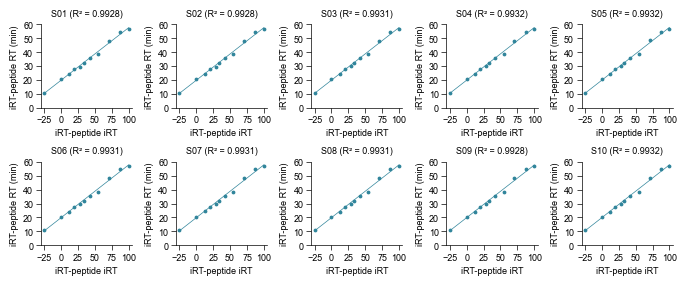

In [11]:
tims2_fit_results = {}
for sample in tims2_iRT.columns:
    iRT_RT_array = tims2_iRT[sample].values
    iRT_iRT_array = iRT_list['iRT'].values
    x = iRT_iRT_array.reshape(-1, 1)  # iRT as x (independent variable)
    y = iRT_RT_array         # RT as y (dependent variable)
    # Generate smooth x values for plotting
    x_fit = np.linspace(min(iRT_iRT_array), max(iRT_iRT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': iRT_RT_array,
            'iRT': iRT_iRT_array
        }
    tims2_fit_results[sample] = sample_results

# Plot fit results
fig, axes = plt.subplots(2, 5, figsize=(6.85, 2.84))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(tims2_fit_results):
    ax = axes[i]
    iRT_RT_array = tims2_fit_results[sample][model_name]['RT']
    iRT_iRT_array = tims2_fit_results[sample][model_name]['iRT']
    ax.scatter(iRT_iRT_array, iRT_RT_array, color = color, alpha = 1.0, s = 3)
    x_fit = tims2_fit_results[sample][model_name]['x_fit']
    y_fit = tims2_fit_results[sample][model_name]['y_fit']
    r2 = tims2_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(-30, 105)
    ax.set_ylim(0, 60)
    ax.set_yticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_xticks([-25, 0, 25, 50, 75, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('iRT-peptide RT (min)')
    ax.set_xlabel('iRT-peptide iRT')
    ax.set_title(f'{sample} (R² = {tims2_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(tims2_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure7/Supplementary_Figure7a_{model_name}_fit_iRT_peptide_RT_vs_iRT_TIMS2.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### Fit iRT-peptide RT (exploris480,Spectronaut) vs. iRT

In [12]:
exploris480_iRT = read_iRT_file('C:/Users/chenxin/Desktop/tmp_results/20251124_480_iRT.csv', iRT_list)
exploris480_iRT = exploris480_iRT[['S01','S02','S03','S04','S05','S06','S07','S08','S11','S12']]
exploris480_iRT.columns = ['S01','S02','S03','S04','S05','S06','S07','S08','S09','S10']
exploris480_iRT

,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10
sequence,,,,,,,,,,
pep a,15.993415,16.057623,15.942040,16.005432,15.881838,16.061308,15.946233,15.882365,16.066603,15.965268
pep b,25.103617,25.053951,25.056791,24.998919,24.993641,24.946541,25.009626,25.004068,25.012001,25.149271
pep c,29.393066,29.343449,29.288733,29.290531,29.283108,29.286310,29.289667,29.284176,29.291388,29.431185
pep d,32.645432,32.537151,32.482082,32.485432,32.475826,32.420357,32.483933,32.478775,32.545418,32.864365
pep e,34.911209,34.872643,34.817169,34.761322,34.751602,34.696144,34.759270,34.814167,34.820831,34.961838
pep f,36.646870,36.658146,36.562069,36.546700,36.537003,36.540745,36.604256,36.598755,36.606018,36.866898
pep g,42.835522,42.790310,42.731831,42.736374,42.725819,42.730236,42.734703,42.787884,42.796543,42.940121
pep h,44.087387,44.042080,43.982666,43.948589,43.977959,43.982086,43.985844,43.980537,44.048275,44.132240
pep i,49.548523,49.504536,49.503548,49.498928,49.499260,49.501827,49.448204,49.502327,49.510105,49.894119


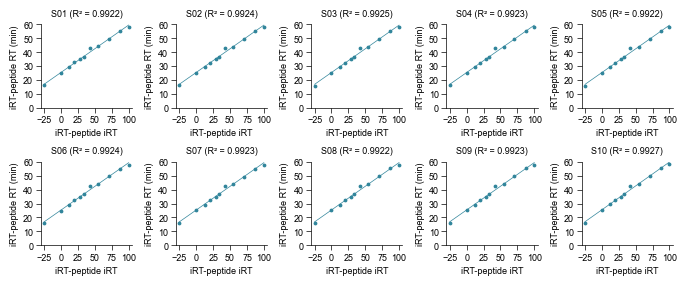

In [13]:
exploris480_fit_results = {}
for sample in exploris480_iRT.columns:
    iRT_RT_array = exploris480_iRT[sample].values
    iRT_iRT_array = iRT_list['iRT'].values
    x = iRT_iRT_array.reshape(-1, 1)  # iRT as x (independent variable)
    y = iRT_RT_array        # RT as y (dependent variable)
    # Generate smooth x values for plotting
    x_fit = np.linspace(min(iRT_iRT_array), max(iRT_iRT_array), 300).reshape(-1, 1)
    sample_results = {}
    for model_name, degree in PR.items():
        model = Pipeline([('poly', PolynomialFeatures(degree = degree)), ('linear', LinearRegression())])
        model.fit(x, y)
        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        y_fit = model.predict(x_fit)
        sample_results[model_name] = {
            'model': model,
            'r2': r2,
            'x_fit': x_fit,
            'y_fit': y_fit,
            'RT': iRT_RT_array,
            'iRT': iRT_iRT_array
        }    
    exploris480_fit_results[sample] = sample_results

# Plot fit results
fig, axes = plt.subplots(2, 5, figsize=(6.85, 2.84))
axes = axes.flatten() 
color = "#31859B"
model_name = 'LR'
for i, sample in enumerate(exploris480_fit_results):
    ax = axes[i]
    iRT_RT_array = exploris480_fit_results[sample][model_name]['RT']
    iRT_iRT_array = exploris480_fit_results[sample][model_name]['iRT']
    ax.scatter(iRT_iRT_array, iRT_RT_array, color = color, alpha = 1.0, s = 3)
    x_fit = exploris480_fit_results[sample][model_name]['x_fit']
    y_fit = exploris480_fit_results[sample][model_name]['y_fit']
    r2 = exploris480_fit_results[sample][model_name]['r2']
    ax.plot(x_fit, y_fit, color = color, alpha = 1.0, linewidth = 0.5)
    ax.set_xlim(-30, 105)
    ax.set_ylim(0, 60)
    ax.set_yticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_xticks([-25, 0, 25, 50, 75, 100])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('iRT-peptide RT (min)')
    ax.set_xlabel('iRT-peptide iRT')
    ax.set_title(f'{sample} (R² = {exploris480_fit_results[sample][model_name]['r2']:.4f})')
for i in range(len(exploris480_fit_results), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout(pad=1.0)
plt.savefig(f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure7/Supplementary_Figure7b_{model_name}_fit_iRT_peptide_RT_vs_iRT_E480.pdf', 
            bbox_inches = 'tight', pad_inches = 0)
plt.show()

### predict iRT of common peptides between tims1 and tims2 based on fitted curve of iRT-peptide iRT vs RT on tims1

In [20]:
tims1_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = list(tims1_peptides), columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

In [21]:
tims1_peptides_iRT['LR']

,iRT
IEVSQLLK,47.76311
HTSVQTTSSGSGPFTDVR,5.99009
YTFAAHMDGTYK,12.405225
LLDAVDTYIPVPAR,81.30536
KLINDYVK,2.810953
...,...
VSVLCQENYLIQEGEEITCK,80.854165
LLELGPKPEVAQQTR,26.843464
RLPIGSYF,61.708843
IYEFPETDDEEENKLVK,34.021057


In [22]:
plasma_peptide_iRT = tims1_peptides_iRT['LR']
plasma_peptide_iRT.to_csv('C:/Users/chenxin/Desktop/BrIS_manuscript/plasma_peptides_iRT_based_on_iRT_peptides.csv')

In [32]:
plasma_peptide_iRT_BrIS = pd.read_csv('C:/Users/chenxin/Desktop/BrIS_manuscript/plasma_peptides_iRT_based_on_BrIS_peptides.csv',index_col = 0)
plasma_peptide_iRT_iRT = pd.read_csv('C:/Users/chenxin/Desktop/BrIS_manuscript/plasma_peptides_iRT_based_on_iRT_peptides.csv', index_col = 0)

In [33]:
df = pd.concat([plasma_peptide_iRT_BrIS, plasma_peptide_iRT_iRT], axis = 1)
df.columns = ['iRT_based_on_BrIS_peptides', 'iRT_based_on_iRT_peptides']
df.to_csv('C:/Users/chenxin/Desktop/BrIS_manuscript/plasma_peptides_iRT.csv')

In [14]:
tims1_tims2_peptides = list(tims1_peptides & tims2_peptides)
tims1_tims2_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = tims1_tims2_peptides, columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_tims2_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_tims2_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

### predict iRT of common peptides between tims1 and exploris480 based on fitted curve of iRT-peptide iRT vs RT on tims1

In [15]:
tims1_exploris480_peptides = list(tims1_peptides & exploris480_peptides)
tims1_exploris480_peptides_iRT = {}
for model_name in PR:
    model_iRT = pd.DataFrame(index = tims1_exploris480_peptides, columns = tims1_bpep_RT_filled.columns)
    for sample in tims1_bpep_RT_filled.columns:
        model = tims1_fit_results[sample][model_name]['model']
        for peptide in tims1_exploris480_peptides:
            experimental_rt = tims1_bpep_RT_filled.loc[peptide, sample]
            if not pd.isna(experimental_rt):
                model_iRT.loc[peptide, sample] = model.predict(np.array([[experimental_rt]]))[0]
    median_iRT = model_iRT.median(axis=1)
    tims1_exploris480_peptides_iRT[model_name] = pd.DataFrame({'iRT': median_iRT})

### predict RT of tims1_tims2_peptides based on fitted curve of iRT-peptide RT vs iRT on tims2

In [16]:
predicted_tims2_bpep_RT = {}
for model_name in PR:
    model_predicted_RT = pd.DataFrame(index=tims1_tims2_peptides, columns=tims2_bpep_RT_filled.columns[0:-1])
    for sample in tims2_bpep_RT_filled.columns[0:-1]:
        model = tims2_fit_results[sample][model_name]['model']
        for peptide in tims1_tims2_peptides:
            irt = tims1_tims2_peptides_iRT[model_name].loc[peptide, 'iRT']  # 使用对应模型的iRT
            if not pd.isna(irt):
                model_predicted_RT.loc[peptide, sample] = model.predict(np.array([[irt]]))[0]
    predicted_tims2_bpep_RT_median = pd.DataFrame({'predicted_RT': model_predicted_RT.median(axis=1)})
    predicted_tims2_bpep_RT[model_name] = predicted_tims2_bpep_RT_median

# combine experimental and predicted RT of background peptides for all models
tims2_bpep_RT_median = pd.DataFrame({'RT': tims2_bpep_RT_filled.median(axis=1)})
tims2_results = {}
for model_name in PR:
    result = pd.concat([tims2_bpep_RT_median, predicted_tims2_bpep_RT[model_name]], axis=1)
    result = result.dropna(subset=['predicted_RT'])
    tims2_results[model_name] = result

### predict RT of tims1_exploris480_peptides based on fitted curve of BrIS RT vs iRT on exploris480

In [17]:
# predict exploris480 bpep RT for all models
predicted_exploris480_bpep_RT = {}
for model_name in PR:
    model_predicted_RT = pd.DataFrame(index=tims1_exploris480_peptides, columns=exploris480_bpep_RT_filled.columns)
    for sample in exploris480_bpep_RT_filled.columns:
        model = exploris480_fit_results[sample][model_name]['model']
        for peptide in tims1_exploris480_peptides:
            irt = tims1_exploris480_peptides_iRT[model_name].loc[peptide, 'iRT']  # 使用对应模型的iRT
            if not pd.isna(irt):
                model_predicted_RT.loc[peptide, sample] = model.predict(np.array([[irt]]))[0]
    predicted_exploris480_bpep_RT_median = pd.DataFrame({'predicted_RT': model_predicted_RT.median(axis=1)})
    predicted_exploris480_bpep_RT[model_name] = predicted_exploris480_bpep_RT_median

# combine experimental and predicted RT of background peptides for all models
exploris480_bpep_RT_median = pd.DataFrame({'RT': exploris480_bpep_RT_filled.median(axis=1)})
exploris480_results = {}
for model_name in PR:
    result = pd.concat([exploris480_bpep_RT_median, predicted_exploris480_bpep_RT[model_name]], axis=1)
    result = result.dropna(subset=['predicted_RT'])
    exploris480_results[model_name] = result

### plot figure: predicted RT vs experimental RT of background peptides

In [36]:
from sklearn.metrics import r2_score
def plot_scatter(results, PR, label, instrument, color, filename):
    for model_name in PR:
        x = results[model_name]['RT'].values
        y = results[model_name]['predicted_RT'].values
        r2 = r2_score(x, y)
        fig, ax = plt.subplots(figsize=(1.53, 1.6))
        scatter = ax.scatter(x, y, alpha = 1.0, s = 8, color = color, edgecolors = 'white', linewidth = 0.02)
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], '--', alpha = 1.0, linewidth = 0.5, color = 'black')
        ax.set_xlim(0, 65) 
        ax.set_ylim(0, 65)
        ax.set_xticks([0,10,20,30,40,50,60])
        ax.set_yticks([0,10,20,30,40,50,60])
        ax.set_xlabel('Experimental RT (min)') 
        ax.set_ylabel('Calibrated RT (min)')
        ax.set_title(instrument)
        textstr = f'R^2 = {r2:.4f}\nn = {len(x):,}'
        props = dict(boxstyle = 'round', facecolor = 'none', edgecolor = 'none', linewidth = 0)
        ax.text(0.05, 0.95, textstr, transform = ax.transAxes, fontsize = 6.5, verticalalignment = 'top', bbox=props)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout(pad = 0)
        plt.savefig(filename)
        plt.show()

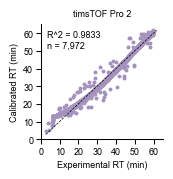

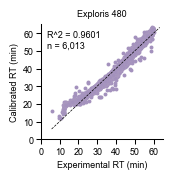

In [37]:
plot_scatter(tims2_results, PR, 'tims2', 'timsTOF Pro 2', '#A391BD',
            f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure8/Supplementary_Figure8e_LR_calibrated_RT_vs_experimental_RT_TIMS2_based_on_iRT_peptides.pdf')
plot_scatter(exploris480_results, PR, '480', 'Exploris 480', '#A391BD',
            f'C:/Users/chenxin/Desktop/BrIS_manuscript/raw_Figures/Supplementary_Figures/Figure8/Supplementary_Figure8f_LR_calibrated_RT_vs_experimental_RT_E480_based_on_iRT_peptides.pdf')

In [23]:
tims1_tims2_peptides_iRT['LR']

,iRT
GSGTAEVELK,-1.971428
HELQANCYEEVKDR,-8.315825
ATWSGAVLAGR,27.636756
QHDMGHMMR,-14.484928
DYPDFSPSVDAEAIQK,49.236009
...,...
LPDATPTELAK,19.219785
LGVQDLFNSSK,60.808372
ADLEMQIESLTEELAYLKK,104.445725
THLAPYSDELRQR,1.324559


In [90]:
tims2_results['LR']

,RT,predicted_RT
FSGSSSGAER,8.125316,13.145169
LTCTLSSGHSSYAIAWHQQQPEK,29.260687,27.638552
LNSDGSHSKGDGIPDR,10.144462,14.137738
FSGSILGNK,26.056133,25.735803
TLIYSTNTR,21.497690,21.84086
...,...,...
SSLPAVSDAR,20.886142,21.14298
VFIGVNDLER,38.914017,38.062449
FYYIVQEEK,32.982147,31.852091
DEAANTLIADYVAK,42.726486,41.93792


In [91]:
tims1_exploris480_peptides_iRT['LR']

,iRT
DEGTAFLVYGAPGFSK,76.756962
RPCFSALEVDETYVPKEFNAETFTFHADICTLSEK,93.575719
YHQGINAEIETR,-1.268661
LLAEPVPGIK,41.86232
LSGNVLSYTFQVK,68.363209
...,...
RVLTDELK,-0.860589
LFAYPDTHR,9.883264
NFDEILR,34.56361
TLQALEFHTVPFQLLAR,99.136274


In [92]:
exploris480_results['LR']

,RT,predicted_RT
LTCTLSSGHSSYAIAWHQQQPEK,32.916346,32.393617
FSGSSSGAER,13.208002,19.392428
FSGSILGNK,31.883113,30.686933
TLIYSTNTR,26.893539,27.190219
FSGSSSGADR,13.058535,19.256312
...,...,...
GSCPTCPEDR,14.328404,19.973438
DEAANTLIADYVAK,47.850571,45.256505
FYYIVQEEK,38.498854,36.177716
VFIGVNDLER,43.135702,41.764592
